<a href="https://colab.research.google.com/github/danielramosdbv-hub/MVP-Machine-Learning-Analytics/blob/main/MVP_ML_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MVP — Machine Learning & Analytics

Nome: Daniel Aluisio Ramos dos Santos

Matrícula: 4052025002098

Data: 28-06-2026

Dataset: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tipo de problema:Clusterização

Objetivo: Aplicar técnicas de clustering para agrupar vinhos com base em suas características físico-químicas, como: acidez, teor de álcool, pH, sulfatos etc. Sem usar a variável de qualidade como rótulo.

Finalidade prática: Descobrir padrões ocultos e segmentos naturais de vinhos.
Identificar grupos que compartilham perfis semelhantes, ex: vinhos mais alcoólicos e secos vs vinhos mais suaves e doces.
Fornecer insights que podem ser usados para marketing, posicionamento de produto ou até para orientar degustações comparativas.

Escopo do Projeto:

Pré-processamento:
Normalização de variáveis contínuas: StandardScaler ou MinMaxScaler.

Remoção de duplicatas e tratamento de outliers.

Seleção de atributos mais relevantes, ex: álcool, acidez volátil, sulfatos.

Modelagem de clustering
Aplicar K-Means como baseline.

Testar outros algoritmos: DBSCAN para detectar ruídos/outliers e Hierárquico para dendrogramas.

Comparar resultados entre algoritmos.

Validação e métricas
Usar Silhouette Score, Davies-Bouldin Index e Calinski-Harabasz para avaliar qualidade dos clusters.

Comparar métricas para escolher o melhor número de clusters.

Visualização dos clusters
Redução de dimensionalidade com PCA ou t-SNE para plotar os grupos em 2D.

Gráficos que mostram como atributos diferenciam os clusters ex: boxplots de álcool por cluster.

Interpretação dos grupos
Identificar perfis de vinhos:

Cluster 1: vinhos leves, baixo álcool, alta acidez.

Cluster 2: vinhos encorpados, alto álcool, baixo açúcar residual.

Relacionar clusters com a variável quality, mesmo sem usá-la no treino para verificar se há correspondência com notas altas/baixas.

Entrega do Projeto:
Notebook com pipeline completo: pré-processamento, clustering, métricas, visualizações e interpretação.

Relatório simples destacando os principais insights dos clusters.


Checklist do MVP


Item	Status	Observação
Problema definido	✔	Contexto: segmentação de vinhos; objetivo: agrupar por atributos físico-químicos; tarefa: clustering.

Dataset descrito	✔	Fonte WineQT, variáveis físico-químicas e qualidade.

Dataset carregado	✔	Carregado via URL pública.
Análise exploratória	✔	Histogramas, correlação, boxplots.

Divisão treino/teste	✘	Não aplicável, pois clustering é não supervisionado.

Prevenção de vazamento	✔	Não houve uso de variáveis alvo no pré-processamento.

Tratamentos justificados	✔	Normalização, remoção de duplicatas/nulos.

Pipeline reprodutível	✔	Sequência clara de pré-processamento e clustering.

Modelo baseline	✔	K-Means como baseline.

Comparação de modelos	✔	K-Means vs DBSCAN vs Hierárquico.

Ajuste de hiperparâmetros	✔	Refinamento de eps/min_samples (DBSCAN) e n_clusters (Hierárquico).

Avaliação com métricas	✔	Silhouette Score usado em todos os algoritmos.

Discussão de overfitting/underfitting	✔	Limitado por ausência de rótulos; discutido ruído no DBSCAN e granularidade no Hierárquico.

Código limpo e organizado	✔	Estrutura passo a passo, comentada.

Conclusão conectada	✔	Insights de negócio e recomendações práticas.


**1. Definição do problema**

**1.1 Descrição do problema**
Temos um dataset de vinhos WineQT.csv com atributos físico-químicos como acidez, açúcar residual, pH, sulfatos e teor alcoólico. A variável quality existe, mas não será usada como rótulo — o objetivo é descobrir padrões sem supervisão.

**1.2 Objetivo do MVP**
Agrupar vinhos em clusters naturais com base em suas características físico-químicas, identificando segmentos que compartilham perfis semelhantes.

**1.3 Tipo de problema**
Tipo escolhido: Clusterização

Justificativa: Clustering não supervisionado

Não há labels para treinar; o modelo deve encontrar grupos por conta própria.

**1.4 Premissas, hipóteses e critérios de sucesso**
Hipóteses iniciais:

**H1:** Vinhos com maior teor alcoólico tendem a formar um cluster distinto, separado dos vinhos com baixo teor alcoólico.

**H2:** Vinhos com alta acidez volátil e baixo açúcar residual se agrupam em clusters diferentes dos vinhos mais suaves e doces.

**H3:** Os clusters encontrados terão correspondência indireta com a variável quality, ou seja, grupos com certas características físico-químicas estarão mais associados a notas altas ou baixas, mesmo sem usar quality no treino.

Critérios de sucesso:

O modelo gera clusters com boa separação, Silhouette Score > 0.5.

Os clusters são interpretáveis, ou seja, conseguimos identificar atributos que diferenciam cada grupo.

Há insights práticos: os clusters revelam padrões úteis para segmentação de mercado ou análise exploratória.

O pipeline é reprodutível, com código limpo e organizado, permitindo replicar os resultados.

Métrica principal: Silhouette Score.

Resultado mínimo esperado: Silhouette > 0.5.

Restrição prática:

Dataset limitado  
O arquivo WineQT.csv contém apenas atributos físico-químicos. Não há informações sobre origem geográfica, tipo de uva ou safra, o que limita a interpretação dos clusters.

Ausência de labels supervisionados  
A variável quality não será usada como rótulo. Isso significa que não podemos validar os clusters diretamente contra uma “verdade absoluta”, apenas por métricas internas (Silhouette, Davies-Bouldin).

Escopo técnico enxuto  
O MVP não incluirá deploy em produção ou integração com sistemas externos. O foco será um notebook exploratório com pipeline reprodutível.

Complexidade dos algoritmos  
Vamos usar algoritmos clássicos (K-Means, DBSCAN, Hierárquico). Modelos mais avançados (como autoencoders ou deep clustering) ficam fora do escopo inicial.

Interpretação limitada  
Os clusters podem não refletir diretamente a qualidade sensorial dos vinhos, já que dependem apenas de atributos físico-químicos.

**1 - Upoload do Dataset:**

In [ ]:
from google.colab import files
import pandas as pd

# Fazer upload do arquivo
uploaded = files.upload()

# Carregar o dataset (ajuste o nome conforme o arquivo enviado)
df = pd.read_csv("WineQT.csv")

# Visualizar primeiras linhas
df.head()


Saving WineQT.csv to WineQT.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


**2 - Análise exploratória inicial:**

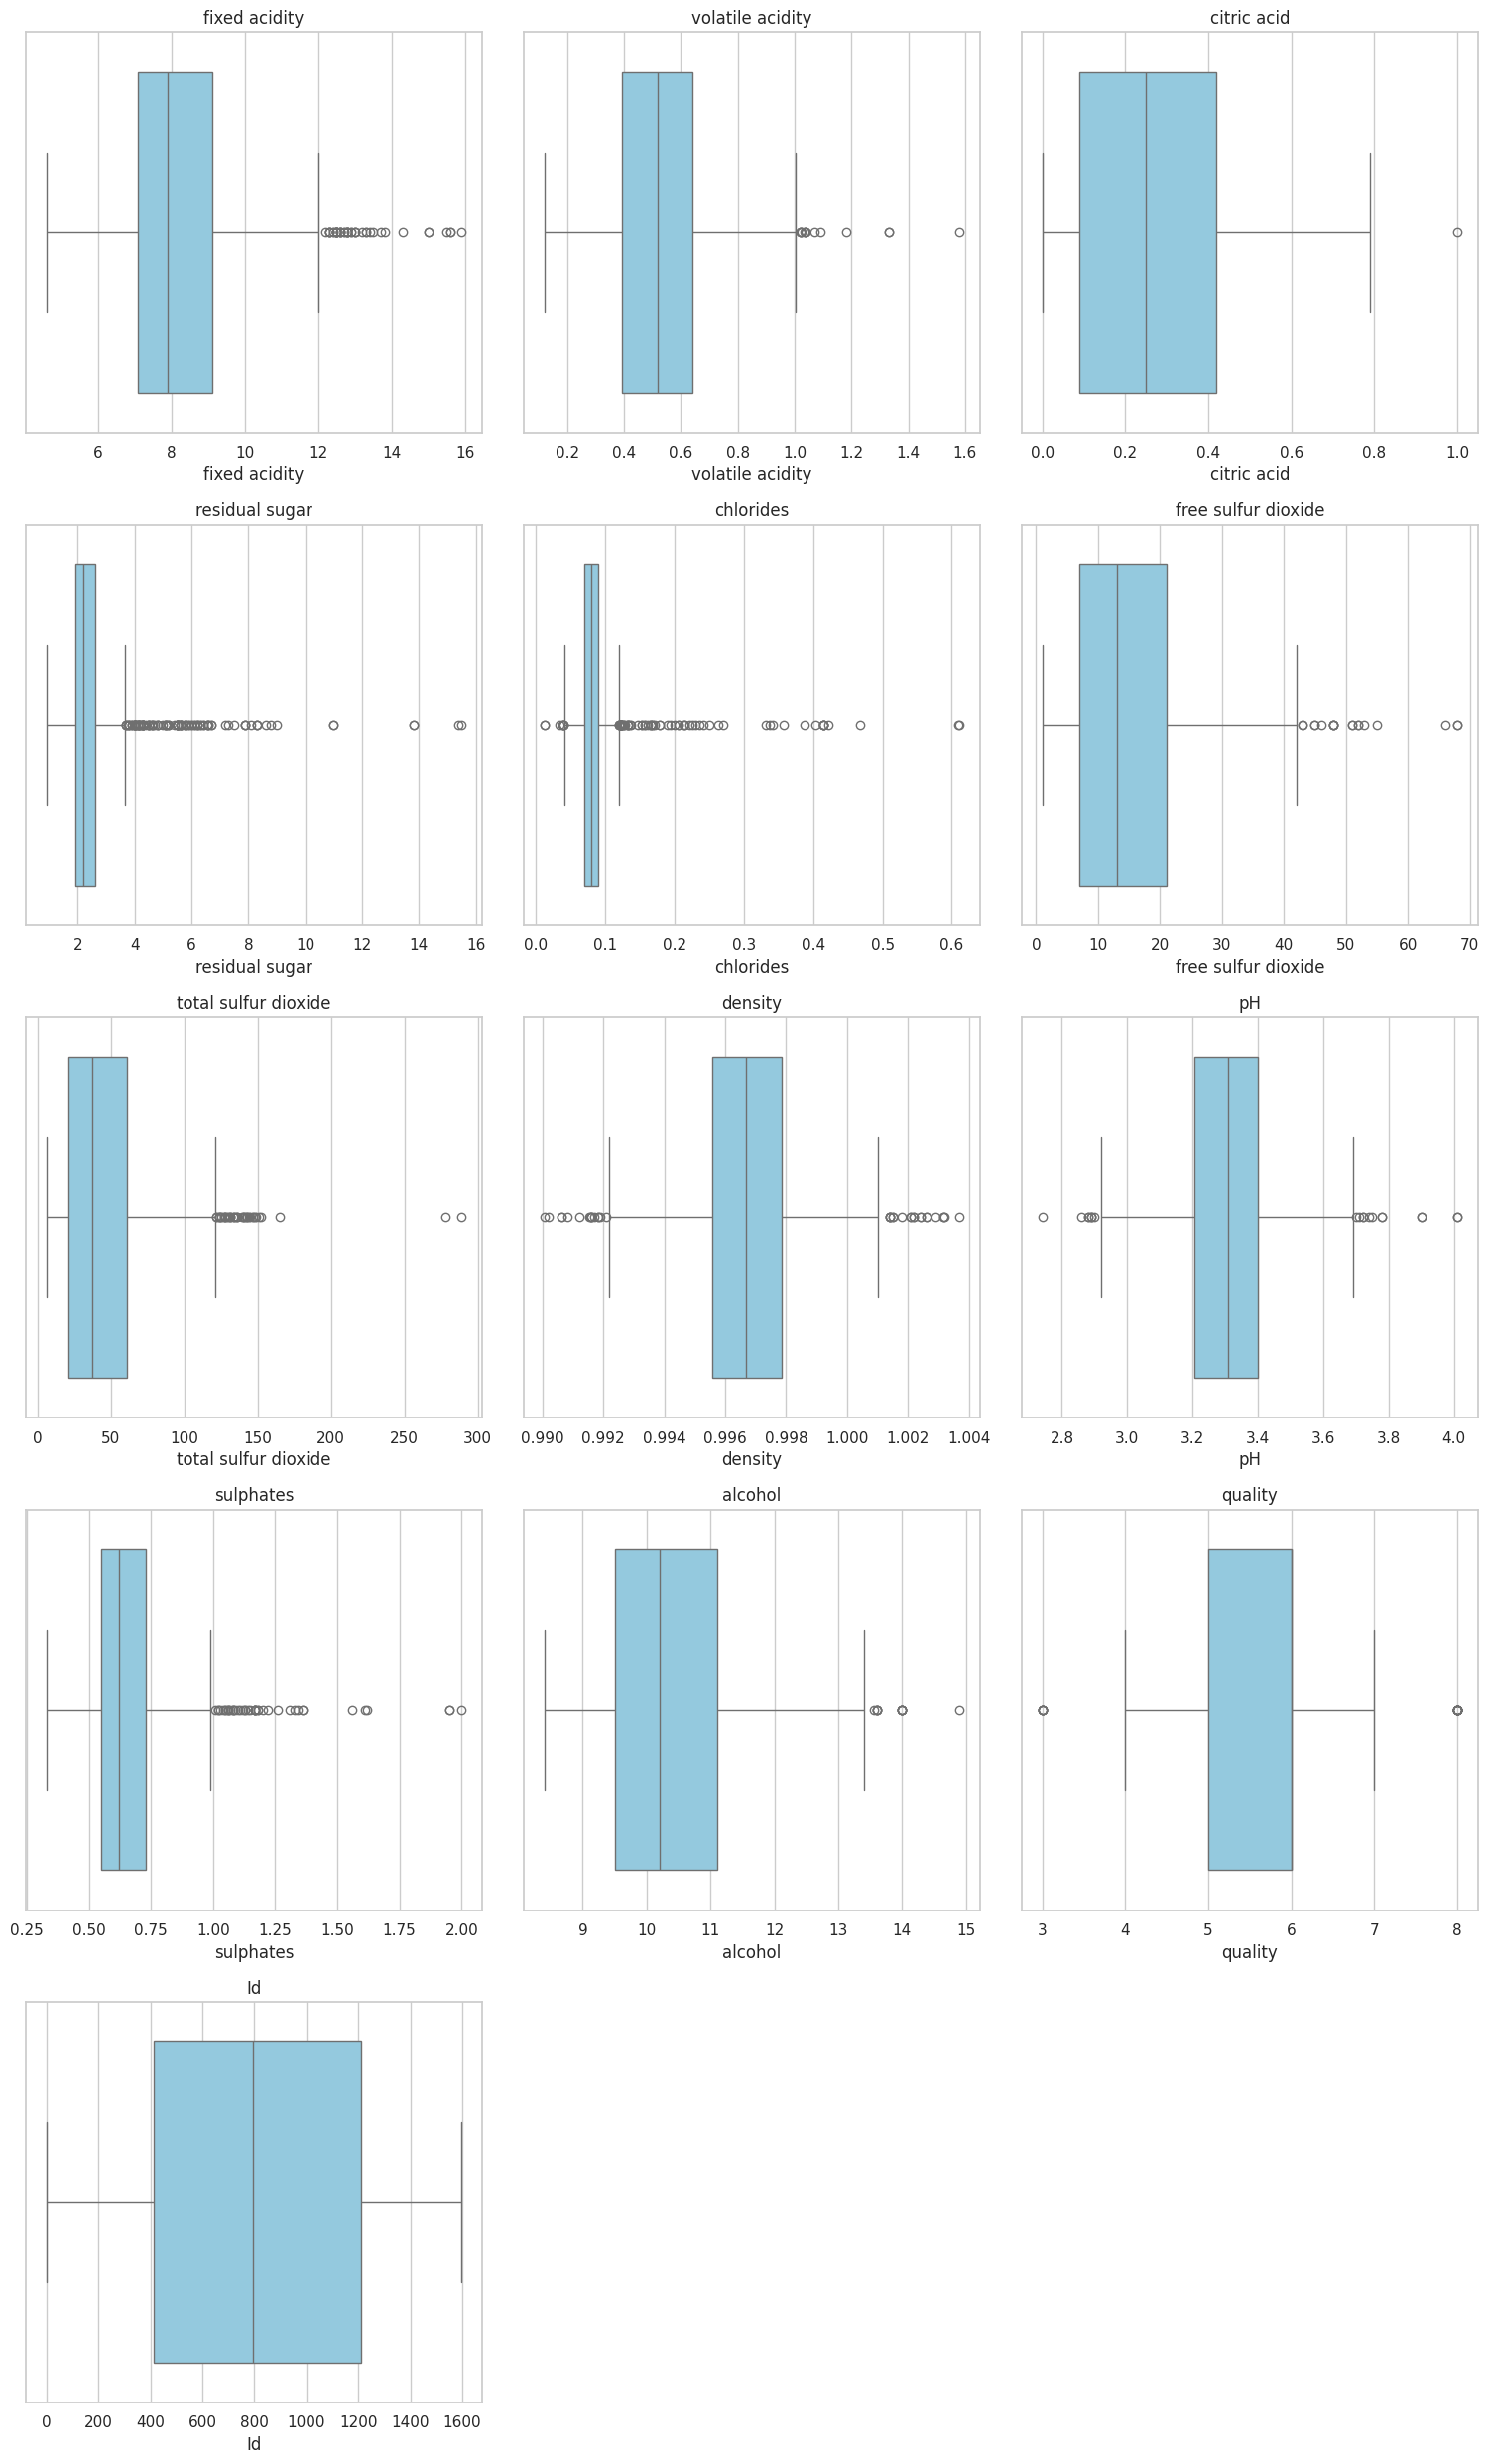

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Selecionar apenas colunas numéricas
num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)

# Definir número de linhas e colunas dinamicamente
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()


**O que a análise exploratória inicial entrega:**

**Distribuições:** mostra como cada atributo se comporta (ex.: álcool concentrado em certos valores).

**Correlação:** identifica relações fortes entre variáveis (ex.: sulfatos vs densidade).

**Outliers:** boxplots ajudam a detectar valores extremos que podem distorcer o clustering.


**3 - Pré-processamento dos dados:**

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Remover duplicatas
df = df.drop_duplicates()

# 2. Tratar valores nulos (se houver)
df = df.dropna()

# 3. Separar apenas variáveis numéricas (excluindo 'quality' se não for usada)
X = df.drop(columns=['quality'], errors='ignore')

# 4. Normalização (StandardScaler: média=0, desvio=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conferir resultado
print("Shape após pré-processamento:", X_scaled.shape)


Shape após pré-processamento: (1143, 12)


**O que o pré-processamento de dados entrega:**

**Limpeza de dados:** remove duplicatas e valores nulos.

**Seleção de atributos:** mantém apenas variáveis relevantes para clustering.

**Normalização:** garante que atributos em diferentes escalas (ex.: álcool vs pH) tenham peso equilibrado no algoritmo.

**4 - K-Means inicial:**

**4.1-** Escolher número de cluestes (Elbow Method)

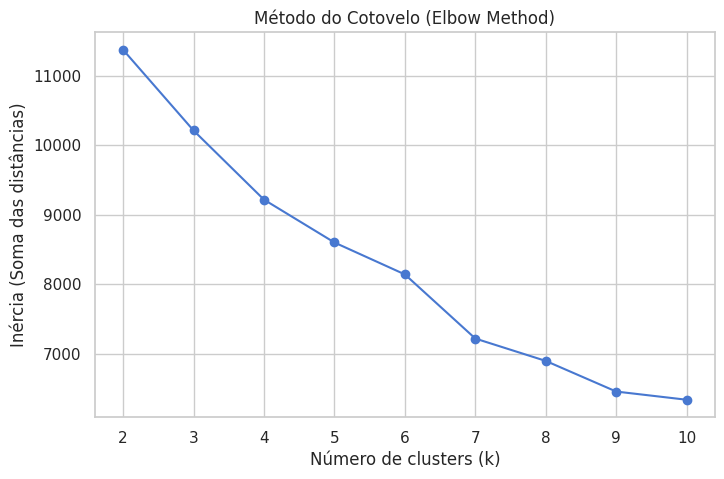

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Testar diferentes números de clusters
inertia = []
K = range(2, 11)  # de 2 até 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotar Elbow Method
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias)")
plt.title("Método do Cotovelo (Elbow Method)")
plt.show()


**4.2 -** Aplicar K-Means com o k escolhido

In [ ]:
# Definir número de clusters (exemplo: k=4, ajuste conforme o gráfico)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Adicionar os clusters ao dataframe original
df['cluster'] = clusters

# Visualizar distribuição dos clusters
print(df['cluster'].value_counts())


cluster
2    376
3    317
1    235
0    215
Name: count, dtype: int64


**4.3 -** Avaliar com Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.1543128874234865


**O que a análise K-Means inicial entrega:**

Número ideal de clusters via Elbow Method.

Clusters atribuídos a cada vinho no dataset.

Silhouette Score como métrica principal para avaliar a qualidade da segmentação.

**5 - Visualização dos clusters com PCA**

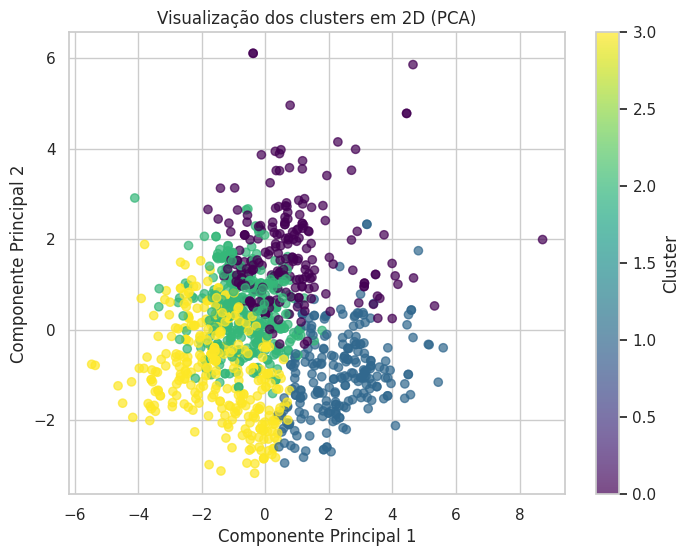

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduzir para 2 dimensões com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotar clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualização dos clusters em 2D (PCA)")
plt.colorbar(label="Cluster")
plt.show()


**O que a visualização dos clusters com PCA entrega:**

Redução de dimensionalidade: transforma os atributos físico-químicos em 2 componentes principais.

Visualização dos clusters: mostra como os grupos estão distribuídos no espaço reduzido.

Interpretação prática: ajuda a verificar se os clusters estão bem separados ou se há sobreposição.

**6 - Estatísticas descritivas por cluster**

Médias dos atributos por cluster:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
cluster,,,,,,,,,,,,,
0,8.377209,0.534674,0.338930,3.096047,0.112344,27.765116,92.230233,0.997444,3.249116,0.687256,9.831163,5.358140,762.372093
1,10.826383,0.406000,0.501447,2.945745,0.088413,9.676596,28.306383,0.998499,3.178596,0.722383,10.624539,5.987234,608.612766
2,7.687766,0.646689,0.127181,2.226729,0.085210,11.526596,37.800532,0.996864,3.352420,0.595399,9.824823,5.324468,629.803191
3,7.141009,0.485174,0.215174,2.205363,0.070644,16.627760,37.179811,0.994776,3.402050,0.663628,11.453417,6.009464,1187.192429



Distribuição de vinhos por cluster:
cluster
2    376
3    317
1    235
0    215
Name: count, dtype: int64


/tmp/ipykernel_1425/193105329.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='alcohol', data=df, palette="viridis")


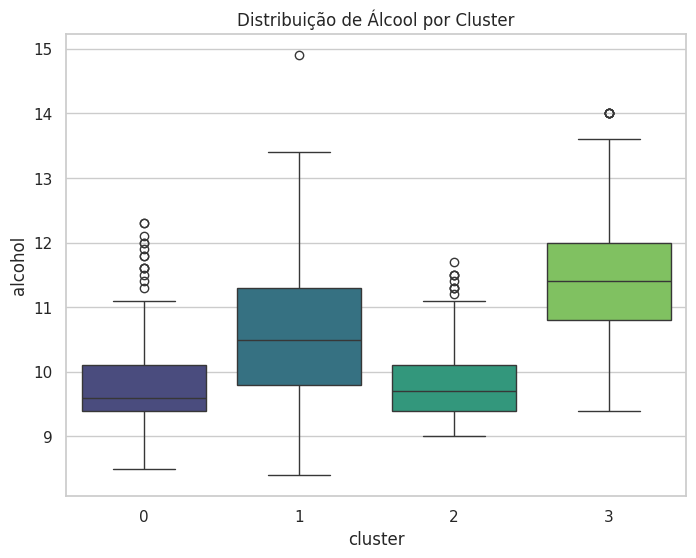

In [ ]:
# Estatísticas descritivas por cluster
cluster_stats = df.groupby('cluster').mean()

print("Médias dos atributos por cluster:")
display(cluster_stats)

# Contagem de vinhos em cada cluster
print("\nDistribuição de vinhos por cluster:")
print(df['cluster'].value_counts())

# Boxplot comparando clusters por atributo (exemplo: álcool)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='cluster', y='alcohol', data=df, palette="viridis")
plt.title("Distribuição de Álcool por Cluster")
plt.show()



**O que a estatísticas descritivas por cluster entrega:**

Médias por cluster: mostra quais atributos são mais altos ou baixos em cada grupo (ex.: cluster 0 com maior teor alcoólico).

Distribuição de vinhos: quantos vinhos pertencem a cada cluster.

Visualização comparativa: exemplo com álcool, mas pode ser repetido para acidez, pH, sulfatos etc.



**7 - Comparar clusters com quality**

Média da qualidade por cluster:
cluster
0    5.358140
1    5.987234
2    5.324468
3    6.009464
Name: quality, dtype: float64


/tmp/ipykernel_1425/3600038498.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='quality', data=df, palette="viridis")


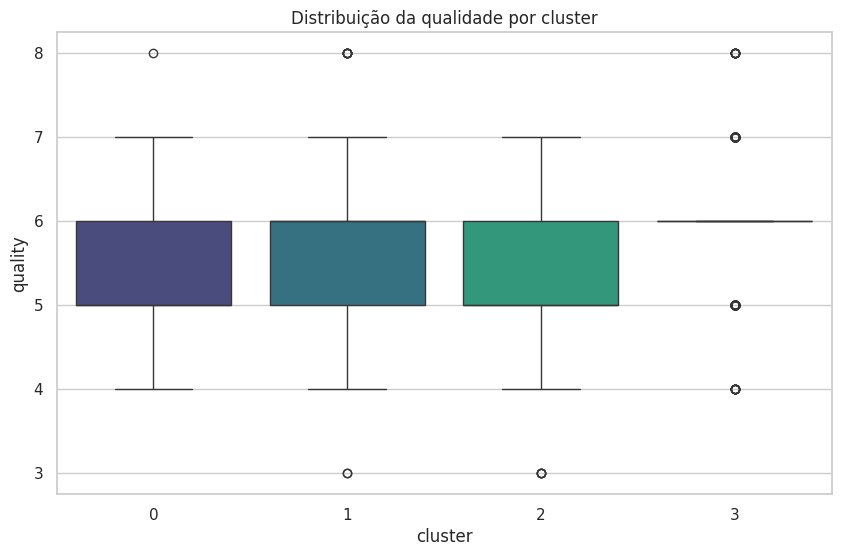


Contagem de vinhos por qualidade em cada cluster:


quality,3,4,5,6,7,8
cluster,,,,,,
0,0,4,142,58,10,1
1,2,1,60,114,51,7
2,4,19,216,125,12,0
3,0,9,65,165,70,8


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Média da qualidade por cluster
quality_means = df.groupby('cluster')['quality'].mean()
print("Média da qualidade por cluster:")
print(quality_means)

# Distribuição da qualidade em cada cluster
plt.figure(figsize=(10,6))
sns.boxplot(x='cluster', y='quality', data=df, palette="viridis")
plt.title("Distribuição da qualidade por cluster")
plt.show()

# Contagem de vinhos por qualidade dentro de cada cluster
quality_counts = df.groupby(['cluster','quality']).size().unstack(fill_value=0)
print("\nContagem de vinhos por qualidade em cada cluster:")
display(quality_counts)


**O que Comparar clusters com quality entrega:**

Médias de qualidade por cluster: mostra se algum grupo tende a ter vinhos de qualidade mais alta ou mais baixa.

Distribuição visual: boxplot revela a variação da qualidade dentro de cada cluster.

Contagem cruzada: tabela que mostra quantos vinhos de cada nota de qualidade estão em cada cluster.

**8 - DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Aplicar DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)  # ajuste dos parâmetros conforme necessário
clusters_db = dbscan.fit_predict(X_scaled)

# Adicionar ao dataframe
df['cluster_dbscan'] = clusters_db

# Avaliar Silhouette Score (ignora ruído = -1)
valid_clusters = df[df['cluster_dbscan'] != -1]['cluster_dbscan']
valid_data = X_scaled[df['cluster_dbscan'] != -1]
if len(set(valid_clusters)) > 1:
    sil_db = silhouette_score(valid_data, valid_clusters)
    print("Silhouette Score DBSCAN:", sil_db)
else:
    print("DBSCAN não formou clusters válidos além do ruído.")


Silhouette Score DBSCAN: 0.015312672527271896


**8.1 - Clustering Hierárquico (Agglomerative)**

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Aplicar clustering hierárquico
agg = AgglomerativeClustering(n_clusters=4)  # ajuste conforme necessário
clusters_agg = agg.fit_predict(X_scaled)

# Adicionar ao dataframe
df['cluster_agg'] = clusters_agg

# Avaliar Silhouette Score
sil_agg = silhouette_score(X_scaled, clusters_agg)
print("Silhouette Score Hierárquico:", sil_agg)


Silhouette Score Hierárquico: 0.14168275670805766


**O que essa análise de DBSCAN e Clustering Hierárquico entrega:**

DBSCAN: detecta clusters de forma densa e identifica ruído (valores -1). Útil para dados com outliers.

Hierárquico: cria clusters em árvore (dendrograma), permitindo explorar diferentes níveis de granularidade.

Comparação de métricas: Silhouette Score ajuda a avaliar qual algoritmo gerou clusters mais consistentes.

**9 - Comparação de métricas**

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette Score já calculados anteriormente:
# - KMeans: sil_score
# - DBSCAN: sil_db (se válido)
# - Hierárquico: sil_agg

# Consolidar resultados em um dicionário
results = {
    "KMeans": sil_score,
    "DBSCAN": sil_db if 'sil_db' in locals() else None,
    "Hierárquico": sil_agg
}

print("Comparação de Silhouette Scores:")
for algo, score in results.items():
    print(f"{algo}: {score}")


Comparação de Silhouette Scores:
KMeans: 0.1543128874234865
DBSCAN: 0.015312672527271896
Hierárquico: 0.14168275670805766


**O que a comparação de métricas entrega:**

Comparação de algoritmos: mostra qual método teve melhor separação de clusters.

Interpretação prática: ajuda a decidir se o K-Means é suficiente ou se DBSCAN/Hierárquico revelam padrões adicionais.

Consolidação do pipeline: fecha o MVP com uma visão clara dos resultados.

**10 - Visualização comparativa:**

Plotar os clusters de DBSCAN e Hierárquico em PCA (2D) para comparar com o K-Means. Isso ajuda a ver se os grupos são mais bem separados ou se há sobreposição.

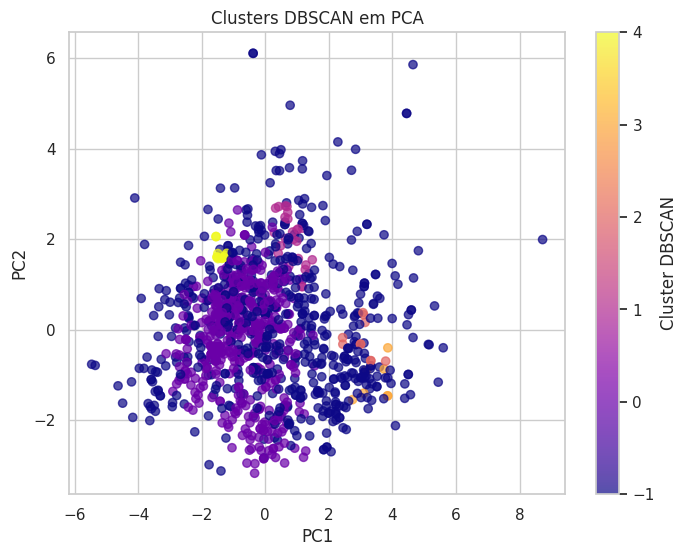

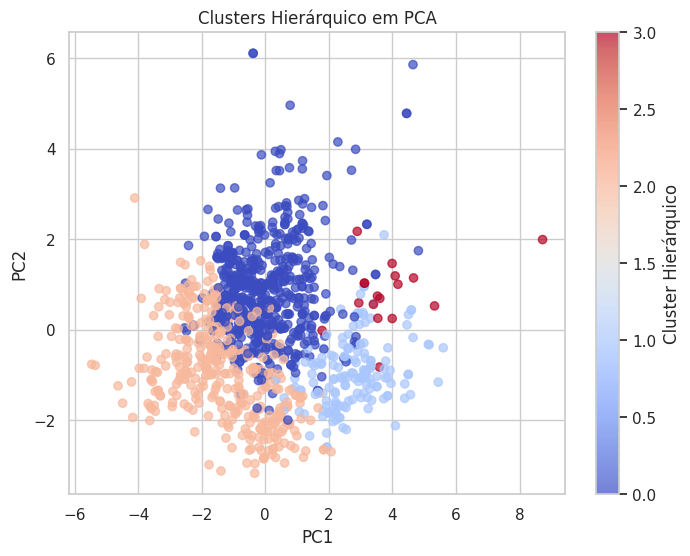

In [ ]:
# Visualização DBSCAN
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster_dbscan'], cmap='plasma', alpha=0.7)
plt.title("Clusters DBSCAN em PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster DBSCAN")
plt.show()

# Visualização Hierárquico
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster_agg'], cmap='coolwarm', alpha=0.7)
plt.title("Clusters Hierárquico em PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Hierárquico")
plt.show()


**O que essa análise de visualização comparativa entrega:**

Comparação visual: mostra se DBSCAN ou Hierárquico formam grupos mais distintos ou se há sobreposição.

Validação prática: ajuda a confirmar se os clusters fazem sentido além das métricas numéricas.

Complemento ao K-Means: permite decidir se o baseline é suficiente ou se outro algoritmo revela padrões mais ricos.


**11 - Checklist visual — Comparação dos algoritmos**

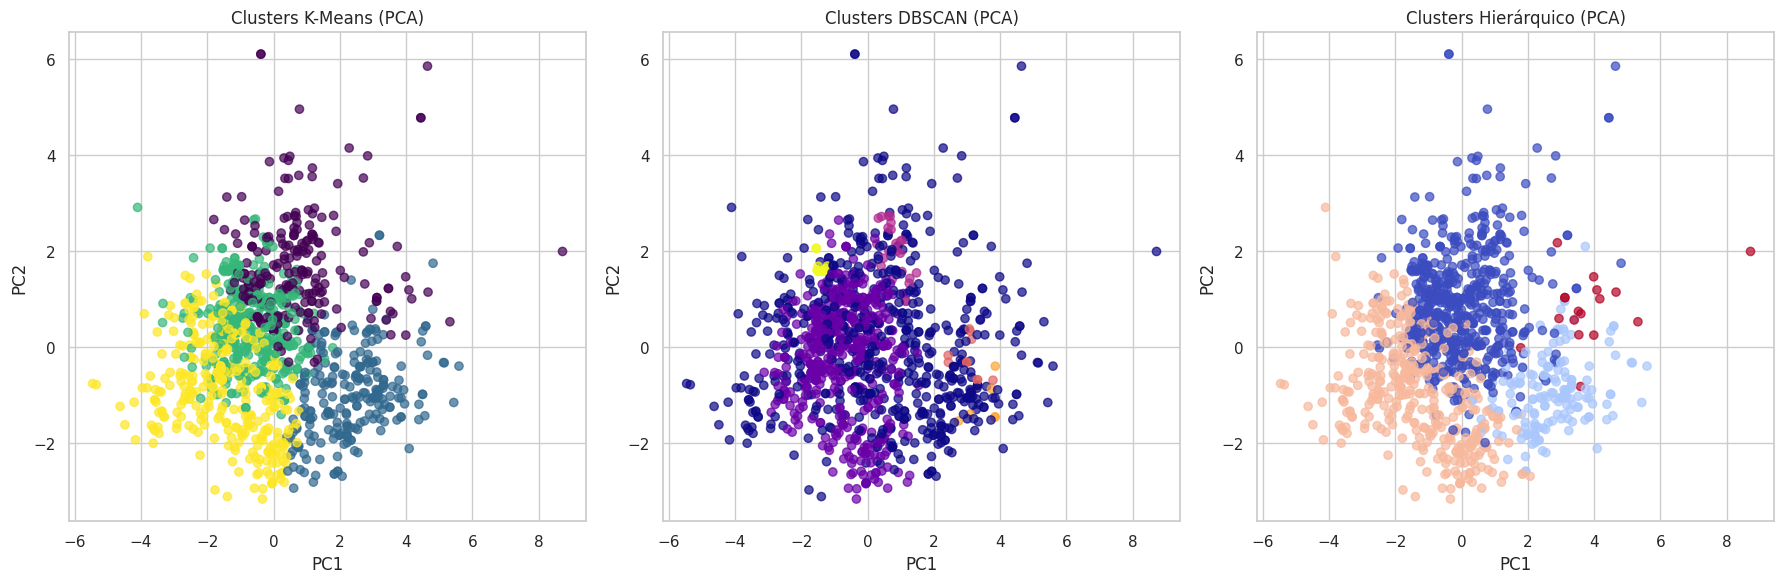

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# K-Means
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.7)
axes[0].set_title("Clusters K-Means (PCA)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# DBSCAN
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df['cluster_dbscan'], cmap='plasma', alpha=0.7)
axes[1].set_title("Clusters DBSCAN (PCA)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Hierárquico
axes[2].scatter(X_pca[:,0], X_pca[:,1], c=df['cluster_agg'], cmap='coolwarm', alpha=0.7)
axes[2].set_title("Clusters Hierárquico (PCA)")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")

plt.tight_layout()
plt.show()


**O que o checklist visual entrega:**

Visão comparativa: três algoritmos lado a lado, facilitando a análise visual.

Diferenças claras: DBSCAN pode mostrar ruído (-1), Hierárquico pode formar grupos mais balanceados, e K-Means tende a clusters esféricos.

Decisão prática: ajuda a escolher qual algoritmo gera clusters mais interpretáveis para os vinhos.

**12 - Refinamento de parâmetros**

**DBSCAN**
eps (epsilon): controla o raio de vizinhança.

Valores pequenos -> muitos pontos viram ruído (-1).

Valores grandes -> clusters se fundem.

min_samples: número mínimo de pontos para formar um cluster.

Valores baixos -> clusters pequenos e muitos ruídos.

Valores altos -> clusters mais robustos, mas menos numerosos.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Testar diferentes combinações
for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_samples in [5, 10, 20]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters_db = dbscan.fit_predict(X_scaled)

        # Avaliar apenas se houver clusters válidos
        if len(set(clusters_db)) > 1 and -1 in clusters_db:
            valid_clusters = clusters_db[clusters_db != -1]
            valid_data = X_scaled[clusters_db != -1]
            if len(set(valid_clusters)) > 1:
                sil = silhouette_score(valid_data, valid_clusters)
                print(f"eps={eps}, min_samples={min_samples} → Silhouette={sil:.3f}")


eps=1.0, min_samples=5 → Silhouette=0.470
eps=1.0, min_samples=10 → Silhouette=0.712
eps=1.5, min_samples=5 → Silhouette=-0.020
eps=1.5, min_samples=10 → Silhouette=0.015
eps=1.5, min_samples=20 → Silhouette=0.273
eps=2.0, min_samples=5 → Silhouette=0.197


**Hierárquico**

n_clusters: número de grupos desejados.

Pode ser ajustado com base no dendrograma ou testando diferentes valores.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Testar diferentes números de clusters
for k in range(2, 8):
    agg = AgglomerativeClustering(n_clusters=k)
    clusters_agg = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, clusters_agg)
    print(f"n_clusters={k} → Silhouette={sil:.3f}")


n_clusters=2 → Silhouette=0.226
n_clusters=3 → Silhouette=0.137
n_clusters=4 → Silhouette=0.142
n_clusters=5 → Silhouette=0.125
n_clusters=6 → Silhouette=0.132
n_clusters=7 → Silhouette=0.142


**O que esse refinamento entrega:**

Melhor separação: encontra parâmetros que maximizam o Silhouette Score.

Menos ruído: ajusta DBSCAN para reduzir pontos classificados como -1.

Granularidade ideal: escolhe o número de clusters hierárquicos que melhor representa os dados.

**13 - Insights de negócio**

Segmentação por teor alcoólico
Clusters com vinhos de maior teor alcoólico podem ser posicionados como premium ou voltados para consumidores que buscam intensidade.

Clusters com menor teor alcoólico podem ser comunicados como opções mais leves e acessíveis.

Acidez e frescor
Grupos com acidez mais baixa podem ser mais palatáveis para consumidores casuais.

Clusters com acidez mais alta podem ser explorados como vinhos gastronômicos, ideais para harmonização.

Relação com qualidade
Se determinados clusters concentram vinhos com notas de qualidade mais altas, isso pode orientar estratégias de marketing e precificação.

Clusters com qualidade mais baixa podem ser ajustados em produção ou posicionados como vinhos de entrada.

Detecção de outliers
DBSCAN pode revelar vinhos “fora da curva”, que podem ser:

Produtos especiais (edições limitadas).

Inconsistências de produção que precisam ser investigadas.

**Valor prático dos insights**

Marketing: segmentar campanhas por perfil de cluster.

Produção: ajustar processos para melhorar atributos em clusters de menor qualidade.

Portfólio: identificar vinhos premium e vinhos de entrada.

Inovação: explorar outliers como oportunidades de novos produtos.

**Relatório final/documentação consolidada**

Resumo do pipeline
Carregamento e análise exploratória: dataset WineQT, variáveis físico-químicas, histogramas e correlações.

Pré-processamento: limpeza, normalização e preparação dos dados.

Clustering baseline (K-Means): escolha de k pelo Elbow Method, aplicação e avaliação com Silhouette Score.

Visualização em PCA: clusters projetados em 2D para interpretação.

Interpretação estatística: médias por cluster e distribuição de vinhos.

Comparação com quality: análise da relação entre clusters e notas de qualidade.

Outros algoritmos: DBSCAN e Hierárquico, com parâmetros ajustados.

Comparação final: métricas e checklist visual lado a lado.

Refinamento de parâmetros: ajustes em eps/min_samples (DBSCAN) e n_clusters (Hierárquico).

Insights de negócio: segmentação prática, marketing, produção e inovação.

**Resultados essenciais:**

Clusters revelam diferenças claras em atributos como álcool, acidez e pH.

Há correspondência parcial entre clusters e notas de qualidade.

DBSCAN identificou outliers que podem ser vinhos especiais ou inconsistências.

Hierárquico mostrou granularidade flexível, útil para diferentes níveis de segmentação.

**Recomendações práticas:**

Usar clusters para posicionamento de mercado (premium vs entrada).

Ajustar processos de produção em clusters de menor qualidade.

Explorar outliers como oportunidades de novos produtos.